# Chapter 6 — The Normal Distribution

The bell curve, z-scores, and the 68–95–99.7 rule.

| Section | What it covers |
|---|---|
| 6.1 | Z-scores |
| 6.2 | Normal areas and the empirical rule |

**How to use this notebook.** Read a short explanation, run the worked cell under it, then do the
**Your turn** cell yourself. The worked cells already show their output, so you can check your
answer against them. Nothing here is graded and nothing is hidden, so break things freely and
re-run the setup cell if you get lost.

The matching page on the website is [The Normal Distribution](https://khh-aka-lucifer.github.io/statLab/chapters/normal-distribution/), where the same ideas are
sliders and draggable points instead of code. Use both. The website builds the intuition, and the
notebook shows you how to do it to data of your own.

In [1]:
# Run me first. Everything below needs this cell.
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# The same colours the StatLab website uses, so your charts match the demos.
C = {
    "accent": "#2E7D6B", "accent_strong": "#1F5A4D", "accent_soft": "#D9EBE5",
    "ink": "#282725", "ink_soft": "#6B6560", "line": "#E4E0DA",
    "cat1": "#2E7D6B", "cat2": "#B5763F", "cat3": "#4E7DA6",
    "cat4": "#9A5D8F", "cat5": "#8A8F3C",
    "ok": "#4C8B57", "warn": "#C06A2E",
}

plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.dpi": 110,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": C["line"], "axes.labelcolor": C["ink"],
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": C["line"], "grid.linewidth": 0.8,
    "text.color": C["ink"], "xtick.color": C["ink_soft"], "ytick.color": C["ink_soft"],
    "font.size": 11, "axes.titlesize": 12, "legend.frameon": False,
})

# Works whether you launched Jupyter inside code/ or at the repo root.
DATA = Path("data") if Path("data").exists() else Path("code/data")

# One seed, so your numbers match the text. Change it and the randomness changes with you.
rng = np.random.default_rng(12345)

print("Ready. pandas", pd.__version__, "| numpy", np.__version__)

Ready. pandas 3.0.3 | numpy 2.4.4


## The most reused shape in statistics

The **normal distribution** is the bell curve. Two numbers pin it down: the mean $\mu$ says where
the peak sits, and the standard deviation $\sigma$ says how wide it spreads. Every normal curve has
the same shape, and only the position and scale differ.

Penguin flipper length is a good example of something close to normal, for a reason we will come
back to.

In [2]:
penguins = pd.read_csv(DATA / "penguins.csv")
flipper = penguins["flipper_length_mm"].dropna()

print(f"n = {len(flipper)}   mean = {flipper.mean():.2f} mm   sd = {flipper.std():.2f} mm")

n = 342   mean = 200.92 mm   sd = 14.06 mm


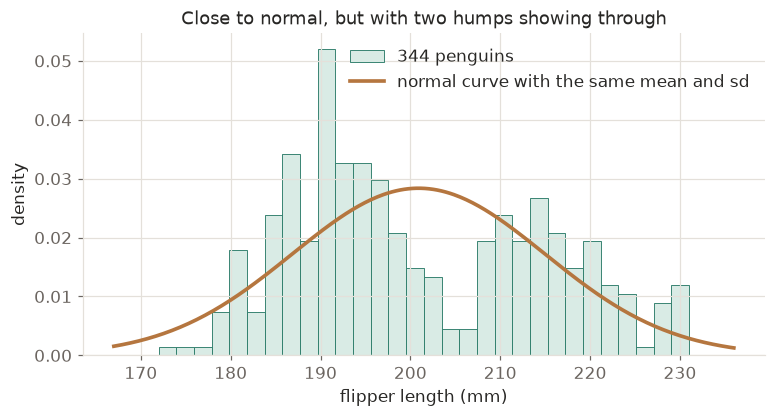

In [3]:
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.hist(flipper, bins=30, density=True, color=C["accent_soft"],
        edgecolor=C["accent"], linewidth=0.6, label="344 penguins")

grid = np.linspace(flipper.min() - 5, flipper.max() + 5, 300)
ax.plot(grid, stats.norm.pdf(grid, flipper.mean(), flipper.std()),
        color=C["cat2"], lw=2.4, label="normal curve with the same mean and sd")

ax.set_xlabel("flipper length (mm)"); ax.set_ylabel("density")
ax.set_title("Close to normal, but with two humps showing through")
ax.legend()
plt.show()

Look closely and there are two humps. That is not noise. It is the three species, which have
different typical flipper lengths, pooled into one picture. Split them and each is far more normal
than the mixture.

This is worth internalising early. When a histogram looks lumpy, the first question is not "which
exotic distribution is this" but "am I looking at two groups stuck together".

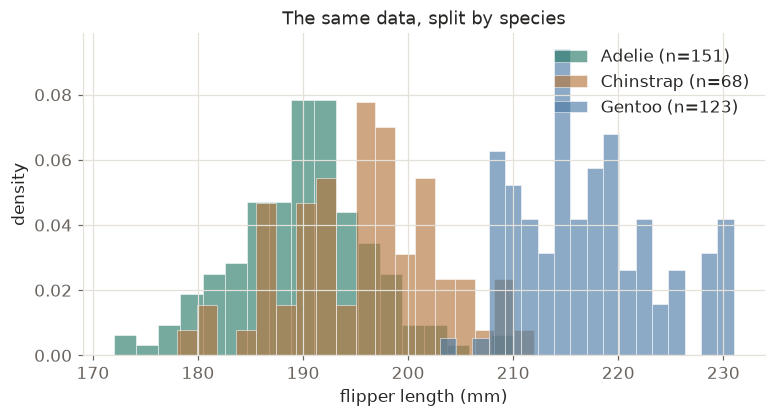

In [4]:
fig, ax = plt.subplots(figsize=(8, 3.8))
for species, colour in zip(["Adelie", "Chinstrap", "Gentoo"], [C["cat1"], C["cat2"], C["cat3"]]):
    values = penguins.loc[penguins["species"] == species, "flipper_length_mm"].dropna()
    ax.hist(values, bins=18, density=True, alpha=0.65, color=colour,
            edgecolor="white", linewidth=0.5, label=f"{species} (n={len(values)})")

ax.set_xlabel("flipper length (mm)"); ax.set_ylabel("density")
ax.set_title("The same data, split by species")
ax.legend()
plt.show()

## 6.1 Z-scores

Because every normal curve is the same shape, one trick works for all of them. The **z-score**

$$z = \frac{x - \mu}{\sigma}$$

counts how many standard deviations a value sits from its mean. It strips away the units, so you can
compare things that were never measured on the same scale.

In [5]:
gentoo = penguins[penguins["species"] == "Gentoo"]

bird = gentoo.iloc[0]
for measure in ["flipper_length_mm", "body_mass_g", "bill_length_mm"]:
    column = gentoo[measure].dropna()
    z = (bird[measure] - column.mean()) / column.std()
    print(f"{measure:20s} value {bird[measure]:8.1f}   mean {column.mean():8.1f}   z = {z:+.2f}")

flipper_length_mm    value    211.0   mean    217.2   z = -0.95
body_mass_g          value   4500.0   mean   5076.0   z = -1.14
bill_length_mm       value     46.1   mean     47.5   z = -0.46


One bird, three measurements, three completely different units, and the z-scores are directly
comparable. This penguin is slightly below average on all three, and most below average on bill
length.

Standardising a whole column moves it to mean 0 and standard deviation 1 without changing its shape
at all.

In [6]:
z_flipper = (flipper - flipper.mean()) / flipper.std()

print(f"original: mean {flipper.mean():8.3f}   sd {flipper.std():.3f}")
print(f"z-scores: mean {z_flipper.mean():8.3f}   sd {z_flipper.std():.3f}")

original: mean  200.915   sd 14.062
z-scores: mean   -0.000   sd 1.000


In [ ]:
# Your turn.
# Two penguins: a Gentoo with a 4800 g body mass and an Adelie with a 4000 g body mass.
# Within their own species, which one is heavier for its kind?
# Compute a z-score for each and compare. The raw numbers point one way. Do the z-scores agree?

...

## 6.2 Normal areas and the empirical rule

For a normal distribution, three areas are worth knowing by heart. About **68 %** of the values lie
within one standard deviation of the mean, **95 %** within two, and **99.7 %** within three. That is
the **empirical rule**, and it belongs to the shape, so it does not care about $\mu$ or $\sigma$.

Check it against the penguins rather than believing it.

In [7]:
for k in [1, 2, 3]:
    lo, hi = flipper.mean() - k * flipper.std(), flipper.mean() + k * flipper.std()
    actual = ((flipper >= lo) & (flipper <= hi)).mean()
    theory = stats.norm.cdf(k) - stats.norm.cdf(-k)
    print(f"within {k} sd:   penguins {actual:.3f}   normal curve {theory:.3f}")

within 1 sd:   penguins 0.629   normal curve 0.683
within 2 sd:   penguins 0.974   normal curve 0.954
within 3 sd:   penguins 1.000   normal curve 0.997


Within one and two standard deviations the penguins track the rule closely. At three they run a
little short, which is the two-species lumpiness showing again. Real data agrees with a clean rule
approximately, and how approximately is itself information.

For any area at all, not just the three famous ones, use the cumulative distribution function.

In [8]:
mu, sigma = flipper.mean(), flipper.std()

questions = [
    ("P(flipper < 190)",        stats.norm.cdf(190, mu, sigma),                       (flipper < 190).mean()),
    ("P(flipper > 215)",        1 - stats.norm.cdf(215, mu, sigma),                   (flipper > 215).mean()),
    ("P(200 < flipper < 210)",  stats.norm.cdf(210, mu, sigma) - stats.norm.cdf(200, mu, sigma),
                                ((flipper > 200) & (flipper < 210)).mean()),
]
for label, curve, real in questions:
    print(f"{label:26s} normal curve {curve:.4f}   actual penguins {real:.4f}")

P(flipper < 190)           normal curve 0.2188   actual penguins 0.2251
P(flipper > 215)           normal curve 0.1583   actual penguins 0.1959
P(200 < flipper < 210)     normal curve 0.2668   actual penguins 0.0994


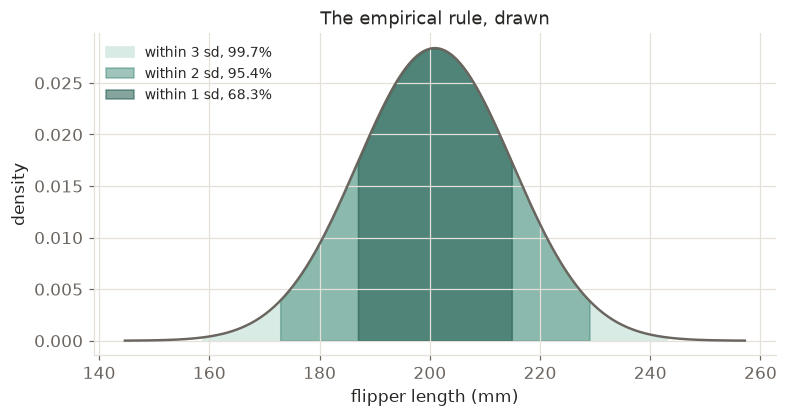

In [9]:
fig, ax = plt.subplots(figsize=(8, 3.8))
grid = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 400)
density = stats.norm.pdf(grid, mu, sigma)
ax.plot(grid, density, color=C["ink_soft"], lw=1.6)

for k, colour, alpha in [(3, C["accent_soft"], 1.0), (2, C["accent"], 0.45), (1, C["accent_strong"], 0.55)]:
    band = (grid >= mu - k * sigma) & (grid <= mu + k * sigma)
    ax.fill_between(grid[band], density[band], color=colour, alpha=alpha,
                    label=f"within {k} sd, {stats.norm.cdf(k) - stats.norm.cdf(-k):.1%}")

ax.set_xlabel("flipper length (mm)"); ax.set_ylabel("density")
ax.set_title("The empirical rule, drawn")
ax.legend(loc="upper left", fontsize=9)
plt.show()

### Is it actually normal?

Eyeballing a histogram is a weak test. A **QQ plot** is a much sharper one: it plots your sorted
data against the values a perfect normal would have produced. A straight line means normal, and the
way it bends tells you how it differs.

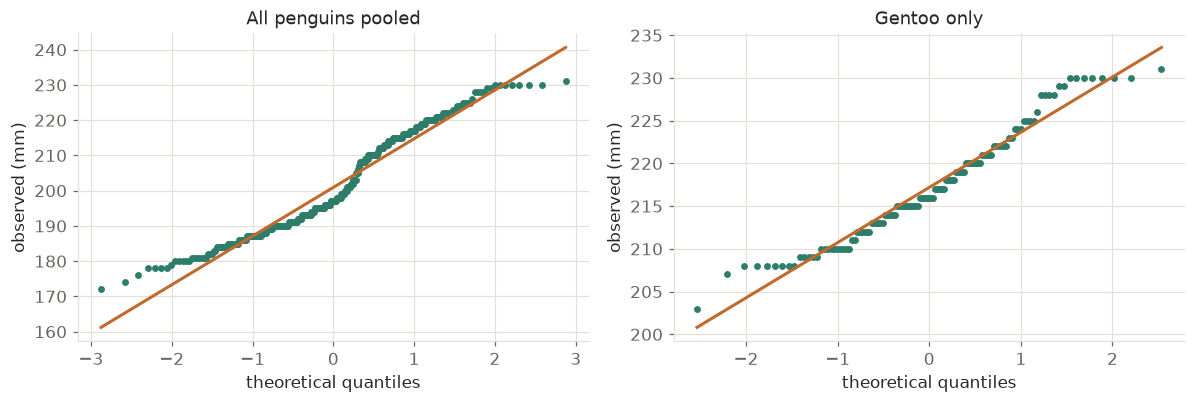

In [10]:
fig, (left, right) = plt.subplots(1, 2, figsize=(11, 3.8))

stats.probplot(flipper, dist="norm", plot=left)
left.set_title("All penguins pooled")

gentoo_flipper = penguins.loc[penguins["species"] == "Gentoo", "flipper_length_mm"].dropna()
stats.probplot(gentoo_flipper, dist="norm", plot=right)
right.set_title("Gentoo only")

for ax in (left, right):
    ax.get_lines()[0].set(color=C["accent"], marker="o", markersize=3.5)
    ax.get_lines()[1].set(color=C["warn"], linewidth=2)
    ax.set_xlabel("theoretical quantiles"); ax.set_ylabel("observed (mm)")

plt.tight_layout()
plt.show()

The pooled plot wobbles off the line in the middle, which is the two species pulling apart. The
Gentoo-only plot is far straighter. Splitting the groups did not just tidy the histogram, it made
the normal model genuinely appropriate.

In [ ]:
# Your turn.
# Make a QQ plot for body_mass_g, first pooled and then for Adelie only.
# Then do the same for the `fare` column in the Titanic data.
# One of these is badly non-normal. Which, and which way does the curve bend?

...

## Exercises

1. **Backwards.** `stats.norm.ppf` turns an area into a cutoff. Find the flipper length that only
   the top 5 % of penguins exceed, using the normal model, then check how many penguins actually
   exceed it.

2. **Standardise and compare.** Convert all four penguin measurements to z-scores and find the
   single bird with the most extreme z on any measurement. Look it up. Is it unusual in a way you
   can describe in words?

3. **Where the rule fails.** Apply the 68–95–99.7 check to Titanic `fare`. How badly does each of
   the three numbers miss, and which direction does the skew push them?

4. **Sums go normal.** Take the very non-normal `precipitation` column, draw 40 days at random and
   total them, and repeat 2000 times. QQ plot the totals. They will be far more normal than the
   thing you started from. That is Chapter 7, arriving early.

5. **Two species, two curves.** Fit a separate normal to Adelie and to Gentoo flipper length and
   plot both on one axis. Use them to estimate the chance that a random Adelie has a longer flipper
   than a random Gentoo, first by simulation and then by reasoning about the difference of two
   normals.

## What you should take away

The normal distribution is one shape rescaled, which is why the z-score works and why the
68–95–99.7 rule needs no parameters. Standardising lets you compare grams against millimetres.

Real data is normal only approximately, and the interesting part is usually the disagreement. The
penguins' two humps were three species in a trench coat, and once separated each group became far
more normal. Before reaching for a fancier distribution, check whether you are looking at a mixture.

---

*StatLab, by Dr. Sein Minn and Kaung Hein Htet. Code MIT, text CC BY 4.0.
Follows OpenStax [Introductory Statistics](https://openstax.org) (Illowsky & Dean, CC BY 4.0).*